# Car Object Detection from Scratch

## Step 1 — Data Preparation

In this project, I am building a simple car object detection system from scratch.

I will use a traffic video as the raw data and convert the video into individual image frames.

The main goal of this step is to prepare the data for annotation and model training.

## Importing OpenCV

I use OpenCV to read and process the video.

A video is essentially a sequence of image frames, so OpenCV allows me to access these frames one by one.

In [46]:
import cv2

## Loading the Video

I load the original traffic video using OpenCV.

At this stage, I am not detecting anything yet. I am only checking whether OpenCV can successfully open and read the video.

In [47]:
video_path = "../data/raw/CarDetectionVideo.mp4"

cap = cv2.VideoCapture(video_path)

print("Video opened:", cap.isOpened())

Video opened: True


## Inspecting the Video

Before extracting frames, I inspect some basic properties of the video, such as its frame rate, resolution, and total number of frames.

This helps me understand the data I am working with.

In [48]:
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = frame_count / fps

print(f"FPS: {fps}")
print(f"Total frames: {frame_count}")
print(f"Resolution: {width} x {height}")
print(f"Duration: {duration:.2f} seconds")

FPS: 30.0
Total frames: 665
Resolution: 1920 x 1080
Duration: 22.17 seconds


## Extracting Frames from the Video

I extracted individual frames from the original video because the object detection model will process images.

The video contains 665 frames at 30 FPS. Instead of using every frame, I sample every 5th frame because consecutive frames are very similar.

This reduces redundant images while keeping enough visual information for the dataset.

In [49]:
import os

frames_dir = "../data/frames"
os.makedirs(frames_dir, exist_ok=True)

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

frame_index = 0
saved_count = 0
frame_interval = 5

while True:
    ret, frame = cap.read()

    if not ret:
        break

    if frame_index % frame_interval == 0:
        frame_name = f"frame_{saved_count:04d}.jpg"
        frame_path = os.path.join(frames_dir, frame_name)

        cv2.imwrite(frame_path, frame)

        saved_count += 1

    frame_index += 1

print(f"Total frames processed: {frame_index}")
print(f"Frames saved: {saved_count}")

Total frames processed: 665
Frames saved: 133


## Step 3 — Image Annotation

I need to tell the model where the cars are located in each image.

I annotate every visible car with a bounding box. Since this project focuses only on cars, I use a single class:

- 0 = car

For each bounding box, I store the class ID and the normalized center coordinates, width, and height.

The annotations will be used as ground-truth data during model training.

In [50]:
import sys

print(sys.version)

3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]


## Step 3.1 — Preparing the Annotation Dataset

### What I am doing

I am preparing the extracted frames for manual image annotation.

Each image may contain one or more cars. I will create a bounding box around every visible car.

Since this project focuses only on cars, I use one class:

- 0 = car

### Why I am doing it

The model needs ground-truth information during training.

The bounding boxes will tell the model:

- which object is a car
- where the car is located in the image

These annotations will later be used to train our own object detection model.

In [51]:
from pathlib import Path

frames_dir = Path("../data/frames")

images = sorted(
    list(frames_dir.glob("*.jpg")) +
    list(frames_dir.glob("*.jpeg")) +
    list(frames_dir.glob("*.png"))
)

print(f"Frames directory: {frames_dir.resolve()}")
print(f"Total images found: {len(images)}")

if images:
    print("\nFirst 5 images:")
    for image in images[:5]:
        print(image.name)
else:
    print("\nNo images were found.")

Frames directory: C:\Users\User\Desktop\Traffic-Object-Detection-with-YOLO\data\frames
Total images found: 133

First 5 images:
frame_0000.jpg
frame_0001.jpg
frame_0002.jpg
frame_0003.jpg
frame_0004.jpg


## Step 3.3 — Creating the Annotation Tool

### What I am doing

I am creating a simple visual annotation tool for our car dataset.

The tool will allow me to:

- open the extracted frames
- draw a bounding box around each visible car
- save the car location as a YOLO annotation
- move between images

Each car will use the class ID:

- 0 = car

### Why I am doing it

The neural network cannot understand where a car is just by looking at the image.

The annotation tool allows me to create the ground-truth bounding boxes that will later be used during model training.

The saved annotations will use normalized coordinates so they can be used by our detection model.

In [52]:
from pathlib import Path

labels_dir = Path("../data/labels")

labels_dir.mkdir(parents=True, exist_ok=True)

print(f"Labels directory: {labels_dir.resolve()}")
print(f"Directory exists: {labels_dir.exists()}")

Labels directory: C:\Users\User\Desktop\Traffic-Object-Detection-with-YOLO\data\labels
Directory exists: True


Image: frame_0000.jpg
Size: (1920, 1080)


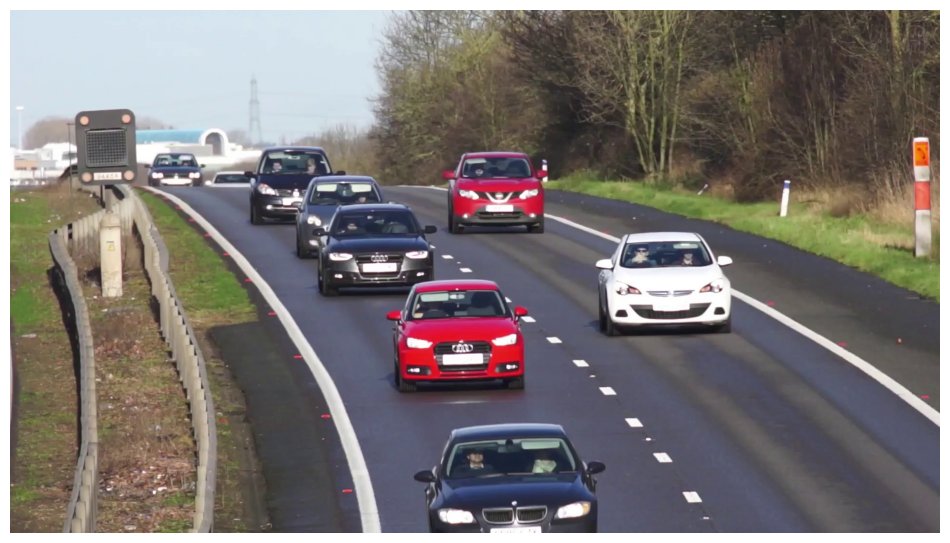

In [53]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(images[0])

print(f"Image: {images[0].name}")
print(f"Size: {image.size}")

plt.figure(figsize=(12, 7))
plt.imshow(image)
plt.axis("off")
plt.show()

## Step 3.4 — Annotation Tool

### What I am doing
I am creating a simple tool to draw bounding boxes around cars.

### Why I am doing it
The boxes will become the ground-truth data used to train our object detector.

- 0 = car
- Coordinates will be saved in YOLO format.

In [54]:
from pathlib import Path

tool_path = Path("../src/annotate.py")

tool_code = r'''
from pathlib import Path
import tkinter as tk
from tkinter import messagebox
from PIL import Image, ImageTk

BASE_DIR = Path(__file__).resolve().parent.parent
FRAMES_DIR = BASE_DIR / "data" / "frames"
LABELS_DIR = BASE_DIR / "data" / "labels"

LABELS_DIR.mkdir(parents=True, exist_ok=True)

images = sorted(
    list(FRAMES_DIR.glob("*.jpg")) +
    list(FRAMES_DIR.glob("*.jpeg")) +
    list(FRAMES_DIR.glob("*.png"))
)

if not images:
    raise RuntimeError("No images found in data/frames")

current_index = 0
boxes = []
start_x = None
start_y = None
temp_rectangle = None

root = tk.Tk()
root.title("Car Annotation Tool")
root.geometry("1300x850")

top_frame = tk.Frame(root)
top_frame.pack(fill="x", padx=10, pady=5)

info_label = tk.Label(top_frame, text="", font=("Arial", 12))
info_label.pack(side="left")

canvas = tk.Canvas(root, bg="black")
canvas.pack(fill="both", expand=True, padx=10, pady=5)

button_frame = tk.Frame(root)
button_frame.pack(pady=8)


def load_image():
    global boxes, start_x, start_y, temp_rectangle

    boxes = []
    start_x = None
    start_y = None
    temp_rectangle = None

    image_path = images[current_index]
    image = Image.open(image_path)

    # Keep the image inside the available canvas area
    max_width = 1200
    max_height = 700

    scale = min(
        max_width / image.width,
        max_height / image.height,
        1
    )

    display_width = int(image.width * scale)
    display_height = int(image.height * scale)

    image = image.resize((display_width, display_height))

    photo = ImageTk.PhotoImage(image)

    canvas.delete("all")
    canvas.config(
        width=display_width,
        height=display_height,
        scrollregion=(0, 0, display_width, display_height)
    )

    canvas.image = photo
    canvas.create_image(0, 0, anchor="nw", image=photo)

    root.image_scale = scale
    root.original_width = Image.open(image_path).width
    root.original_height = Image.open(image_path).height

    info_label.config(
        text=f"{current_index + 1}/{len(images)}  |  {image_path.name}  |  Boxes: 0"
    )


def mouse_down(event):
    global start_x, start_y, temp_rectangle

    start_x = event.x
    start_y = event.y

    temp_rectangle = canvas.create_rectangle(
        start_x,
        start_y,
        start_x,
        start_y,
        outline="red",
        width=2
    )


def mouse_drag(event):
    if temp_rectangle is not None:
        canvas.coords(
            temp_rectangle,
            start_x,
            start_y,
            event.x,
            event.y
        )


def mouse_up(event):
    global start_x, start_y, temp_rectangle

    if start_x is None or start_y is None:
        return

    x1 = min(start_x, event.x)
    y1 = min(start_y, event.y)
    x2 = max(start_x, event.x)
    y2 = max(start_y, event.y)

    width = x2 - x1
    height = y2 - y1

    if width < 5 or height < 5:
        canvas.delete(temp_rectangle)
        temp_rectangle = None
        start_x = None
        start_y = None
        return

    boxes.append((x1, y1, x2, y2))

    canvas.itemconfig(temp_rectangle, outline="lime")

    temp_rectangle = None
    start_x = None
    start_y = None

    update_info()


def update_info():
    info_label.config(
        text=f"{current_index + 1}/{len(images)}  |  "
             f"{images[current_index].name}  |  "
             f"Boxes: {len(boxes)}"
    )


def undo_box():
    if boxes:
        boxes.pop()
        canvas.delete("all")
        redraw()
        update_info()


def redraw():
    image_path = images[current_index]
    image = Image.open(image_path)

    scale = root.image_scale

    display_width = int(image.width * scale)
    display_height = int(image.height * scale)

    image = image.resize((display_width, display_height))
    photo = ImageTk.PhotoImage(image)

    canvas.delete("all")
    canvas.image = photo
    canvas.create_image(0, 0, anchor="nw", image=photo)

    for box in boxes:
        canvas.create_rectangle(
            *box,
            outline="lime",
            width=2
        )


def save_labels():
    if not boxes:
        messagebox.showwarning(
            "No boxes",
            "Draw at least one bounding box around a car."
        )
        return

    image_path = images[current_index]
    label_path = LABELS_DIR / f"{image_path.stem}.txt"

    scale = root.image_scale

    lines = []

    for x1, y1, x2, y2 in boxes:

        # Convert display coordinates to original image coordinates
        x1_original = x1 / scale
        y1_original = y1 / scale
        x2_original = x2 / scale
        y2_original = y2 / scale

        # YOLO normalized coordinates
        x_center = ((x1_original + x2_original) / 2) / root.original_width
        y_center = ((y1_original + y2_original) / 2) / root.original_height

        width = (x2_original - x1_original) / root.original_width
        height = (y2_original - y1_original) / root.original_height

        lines.append(
            f"0 {x_center:.6f} {y_center:.6f} "
            f"{width:.6f} {height:.6f}"
        )

    label_path.write_text(
        "\n".join(lines),
        encoding="utf-8"
    )

    info_label.config(
        text=f"{current_index + 1}/{len(images)}  |  "
             f"{image_path.name}  |  "
             f"Saved: {label_path.name}  |  "
             f"Boxes: {len(boxes)}"
    )


def next_image():
    global current_index

    save_labels()

    if current_index < len(images) - 1:
        current_index += 1
        load_image()


def previous_image():
    global current_index

    if current_index > 0:
        current_index -= 1
        load_image()


def skip_image():
    global current_index

    if current_index < len(images) - 1:
        current_index += 1
        load_image()


canvas.bind("<ButtonPress-1>", mouse_down)
canvas.bind("<B1-Motion>", mouse_drag)
canvas.bind("<ButtonRelease-1>", mouse_up)

tk.Button(
    button_frame,
    text="Previous",
    command=previous_image,
    width=12
).pack(side="left", padx=5)

tk.Button(
    button_frame,
    text="Undo",
    command=undo_box,
    width=12
).pack(side="left", padx=5)

tk.Button(
    button_frame,
    text="SAVE",
    command=save_labels,
    width=12
).pack(side="left", padx=5)

tk.Button(
    button_frame,
    text="Skip",
    command=skip_image,
    width=12
).pack(side="left", padx=5)

tk.Button(
    button_frame,
    text="Next",
    command=next_image,
    width=12
).pack(side="left", padx=5)

load_image()

root.mainloop()
'''

tool_path.write_text(tool_code, encoding="utf-8")

print(f"Annotation tool created:")
print(tool_path.resolve())

Annotation tool created:
C:\Users\User\Desktop\Traffic-Object-Detection-with-YOLO\src\annotate.py


In [55]:
from pathlib import Path

labels_dir = Path("../data/labels")

label_files = sorted(labels_dir.glob("*.txt"))

print("Label files:", len(label_files))

for file in label_files[:5]:
    print(f"\n{file.name}")
    print(file.read_text(encoding="utf-8"))

Label files: 14

frame_0000.txt
0 0.705833 0.528889 0.155000 0.204444
0 0.525000 0.348889 0.123333 0.173333
0 0.485000 0.622963 0.156667 0.226667
0 0.534583 0.890370 0.217500 0.219259
0 0.397500 0.461481 0.125000 0.179259
0 0.302500 0.329630 0.091667 0.155556
0 0.354583 0.382963 0.109167 0.179259
0 0.178333 0.302963 0.065000 0.093333
0 0.236667 0.319259 0.055000 0.063704

frame_0001.txt
0 0.180000 0.297037 0.065000 0.099259
0 0.242083 0.317778 0.059167 0.060741
0 0.308750 0.334815 0.095833 0.180741
0 0.361667 0.395556 0.106667 0.160000
0 0.403333 0.460741 0.130000 0.174815
0 0.492083 0.648148 0.169167 0.232593
0 0.532917 0.349630 0.110833 0.183704
0 0.718750 0.539259 0.155833 0.225185
0 0.540833 0.917037 0.200000 0.165926

frame_0002.txt
0 0.186667 0.298519 0.061667 0.099259
0 0.247500 0.320741 0.051667 0.069630
0 0.543333 0.362963 0.110000 0.157037
0 0.732917 0.562963 0.150833 0.192593
0 0.504167 0.679259 0.156667 0.223704
0 0.317500 0.342963 0.093333 0.155556
0 0.368333 0.413333 0.11

In [56]:
invalid = []

for file in label_files:
    lines = file.read_text(encoding="utf-8").strip().splitlines()

    for line_num, line in enumerate(lines, 1):
        parts = line.split()

        if len(parts) != 5:
            invalid.append((file.name, line_num, "wrong number of values"))
            continue

        try:
            values = list(map(float, parts))
        except ValueError:
            invalid.append((file.name, line_num, "non-numeric value"))
            continue

        class_id, x, y, w, h = values

        if class_id != 0:
            invalid.append((file.name, line_num, "class is not 0"))

        if not all(0 <= v <= 1 for v in [x, y, w, h]):
            invalid.append((file.name, line_num, "coordinate outside 0-1"))

print("Total labels:", len(label_files))
print("Invalid annotations:", len(invalid))

if invalid:
    for item in invalid[:10]:
        print(item)
else:
    print("All annotations are valid!")

Total labels: 14
Invalid annotations: 0
All annotations are valid!


## Step 4 — Dataset Split

### What I am doing
I am splitting the annotated images into training, validation, and test sets.

- 70% → Train
- 15% → Validation
- 15% → Test

### Why I am doing it
The model needs separate data for learning, validation, and final evaluation.
Only images with valid annotations will be included.

In [57]:
from pathlib import Path
import random
import shutil

random.seed(42)

BASE_DIR = Path("../data")
FRAMES_DIR = BASE_DIR / "frames"
LABELS_DIR = BASE_DIR / "labels"

DATASET_DIR = BASE_DIR / "dataset"

for split in ["train", "val", "test"]:
    (DATASET_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

# Only images that have a label file
images = []

for image in FRAMES_DIR.glob("*"):
    if image.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        label = LABELS_DIR / f"{image.stem}.txt"
        if label.exists():
            images.append(image)

random.shuffle(images)

n = len(images)

train_end = int(n * 0.70)
val_end = train_end + int(n * 0.15)

train_images = images[:train_end]
val_images = images[train_end:val_end]
test_images = images[val_end:]

print("Total annotated images:", n)
print("Train:", len(train_images))
print("Validation:", len(val_images))
print("Test:", len(test_images))

Total annotated images: 14
Train: 9
Validation: 2
Test: 3


## Step 4.1 — Organizing the Dataset

### What I am doing
I am copying each image and its annotation into the correct dataset split.

### Why I am doing it
Keeping images and labels organized makes the dataset easier to use during training.

In [58]:
def copy_split(image_list, split):
    for image in image_list:
        label = LABELS_DIR / f"{image.stem}.txt"

        shutil.copy2(
            image,
            DATASET_DIR / "images" / split / image.name
        )

        shutil.copy2(
            label,
            DATASET_DIR / "labels" / split / label.name
        )


copy_split(train_images, "train")
copy_split(val_images, "val")
copy_split(test_images, "test")

print("Dataset split completed.")

Dataset split completed.


## Step 4.2 — Checking the Dataset

### What I am doing
I am checking that every image has a corresponding annotation.

### Why I am doing it
Each training image must have the correct label file.

In [59]:
for split in ["train", "val", "test"]:
    image_dir = DATASET_DIR / "images" / split
    label_dir = DATASET_DIR / "labels" / split

    image_files = list(image_dir.glob("*"))
    label_files = list(label_dir.glob("*.txt"))

    print(f"{split}:")
    print(f"  Images: {len(image_files)}")
    print(f"  Labels: {len(label_files)}")

train:
  Images: 9
  Labels: 9
val:
  Images: 2
  Labels: 2
test:
  Images: 3
  Labels: 3


## Step 5 — Visualizing Annotations

### What I am doing
I am displaying an image together with its ground-truth bounding boxes.

### Why I am doing it
This helps verify that the annotations are correctly aligned with the cars before training.

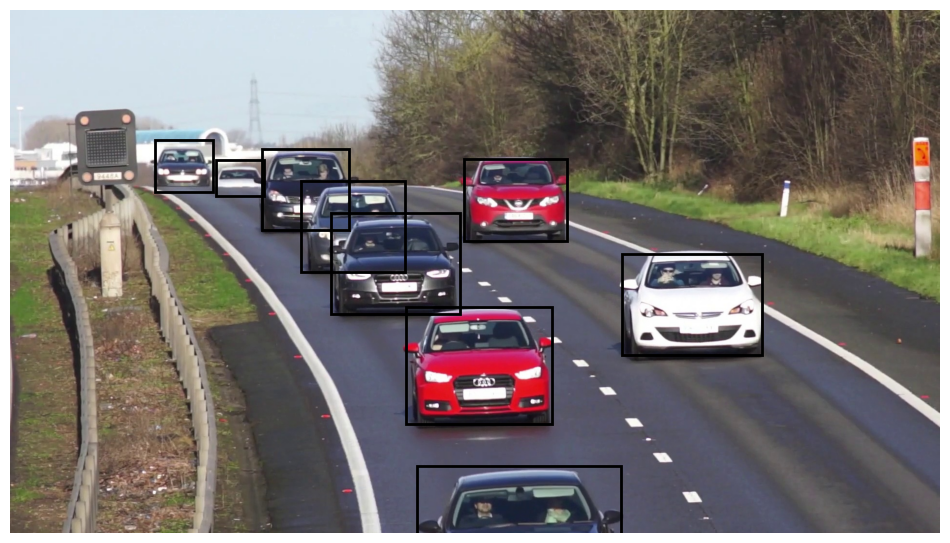

In [60]:
from PIL import Image
import matplotlib.pyplot as plt

train_images_dir = DATASET_DIR / "images" / "train"
train_labels_dir = DATASET_DIR / "labels" / "train"

sample_image = sorted(train_images_dir.glob("*"))[0]
sample_label = train_labels_dir / f"{sample_image.stem}.txt"

image = Image.open(sample_image)
width, height = image.size

plt.figure(figsize=(12, 7))
plt.imshow(image)

with open(sample_label, "r") as f:
    for line in f:
        parts = line.strip().split()

        class_id, x, y, w, h = map(float, parts)

        x1 = (x - w / 2) * width
        y1 = (y - h / 2) * height
        box_width = w * width
        box_height = h * height

        rect = plt.Rectangle(
            (x1, y1),
            box_width,
            box_height,
            fill=False,
            linewidth=2
        )

        plt.gca().add_patch(rect)

plt.axis("off")
plt.show()

## Step 6 — Creating the Dataset Class

### What I am doing
I am creating a PyTorch Dataset that loads images and their bounding-box annotations.

### Why I am doing it
The neural network needs the images and ground-truth boxes in a format that PyTorch can process during training.

In [61]:
import torch
from torch.utils.data import Dataset
from PIL import Image
from pathlib import Path


class CarDataset(Dataset):

    def __init__(self, image_dir, label_dir, image_size=224):
        self.image_dir = Path(image_dir)
        self.label_dir = Path(label_dir)
        self.image_size = image_size

        self.images = sorted([
            p for p in self.image_dir.iterdir()
            if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):

        image_path = self.images[index]
        label_path = self.label_dir / f"{image_path.stem}.txt"

        image = Image.open(image_path).convert("RGB")

        image = image.resize((self.image_size, self.image_size))

        image = torch.tensor(
            list(image.getdata()),
            dtype=torch.float32
        )

        image = image.view(
            self.image_size,
            self.image_size,
            3
        ).permute(2, 0, 1) / 255.0

        labels = []

        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) == 5:
                    labels.append([
                        float(x) for x in parts
                    ])

        labels = torch.tensor(
            labels,
            dtype=torch.float32
        )

        return image, labels

## Step 6.1 — Testing the Dataset

I am loading one training sample from the dataset.

I want to make sure that the images and annotations can be loaded correctly before building the model.

In [62]:
train_dataset = CarDataset(
    DATASET_DIR / "images" / "train",
    DATASET_DIR / "labels" / "train"
)

image, labels = train_dataset[0]

print("Dataset size:", len(train_dataset))
print("Image shape:", image.shape)
print("Labels shape:", labels.shape)
print("Labels:")
print(labels)

Dataset size: 9
Image shape: torch.Size([3, 224, 224])
Labels shape: torch.Size([9, 5])
Labels:
tensor([[0.0000, 0.1867, 0.2985, 0.0617, 0.0993],
        [0.0000, 0.2475, 0.3207, 0.0517, 0.0696],
        [0.0000, 0.5433, 0.3630, 0.1100, 0.1570],
        [0.0000, 0.7329, 0.5630, 0.1508, 0.1926],
        [0.0000, 0.5042, 0.6793, 0.1567, 0.2237],
        [0.0000, 0.3175, 0.3430, 0.0933, 0.1556],
        [0.0000, 0.3683, 0.4133, 0.1117, 0.1748],
        [0.0000, 0.4142, 0.4844, 0.1383, 0.1926],
        [0.0000, 0.5471, 0.9393, 0.2192, 0.1363]])


C:\Users\User\AppData\Local\Temp\ipykernel_22700\3426364149.py:32: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  list(image.getdata()),


## Step 7 — Detection Model

I am building a simple CNN-based object detector from scratch.

The CNN will learn visual features and predict the location and confidence of cars.

The model will predict:

- x
- y
- width
- height
- confidence

## Step 7.1 — CNN Feature Extractor
I am creating convolutional layers that extract visual features from the input image.
The CNN needs to learn patterns such as edges, shapes, wheels, and car structures before predicting bounding boxes.

In [63]:
import torch
import torch.nn as nn


class CarDetector(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # 224 x 224
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 112 x 112
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 56 x 56
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 28 x 28
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 14 x 14
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool2d((7, 7))

        self.detection_head = nn.Conv2d(
            256,
            5,
            kernel_size=1
        )

    def forward(self, x):

        x = self.features(x)

        x = self.pool(x)

        x = self.detection_head(x)

        return x

## Step 7.2 — Creating the Model

Noü, I am creating an instance of our CNN detector.

This is the neural netüork that üill later learn to detect cars from our annotated images.

In [64]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = CarDetector().to(device)

print(model)
print("\nDevice:", device)

CarDetector(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
  )
  (pool): AdaptiveAvgPool2d(output_size=(7, 7))
  (detection_head): Conv2d(256, 5, kernel_size=(1, 1), stride=(1, 1))
)

Device: cpu


## Step 7.3 — Testing the Model Output

I am passing one image through the CNN and checking its output shape.

Before training, we need to verify that the detection head produces the expected prediction structure.

In [65]:
sample_image = image.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(sample_image)

print("Input shape:", sample_image.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([1, 3, 224, 224])
Output shape: torch.Size([1, 5, 7, 7])


## Step 8 — Creating the Target Grid

I am converting the YOLO bounding-box annotations into a 7×7 grid representation.

Our CNN predicts one bounding box and confidence value for each grid cell, so the ground-truth data must use the same structure.

In [66]:
GRID_SIZE = 7


def create_target(labels):

    target = torch.zeros(
        GRID_SIZE,
        GRID_SIZE,
        5
    )

    for label in labels:

        class_id, x, y, w, h = label

        # Find the grid cell
        grid_x = min(int(x * GRID_SIZE), GRID_SIZE - 1)
        grid_y = min(int(y * GRID_SIZE), GRID_SIZE - 1)

        # Coordinates inside the grid cell
        cell_x = x * GRID_SIZE - grid_x
        cell_y = y * GRID_SIZE - grid_y

        target[grid_y, grid_x] = torch.tensor([
            cell_x,
            cell_y,
            w,
            h,
            1.0
        ])

    return target

## Step 8.1 — Testing the Target Representation

### What I am doing
I am converting one image's annotations into the 7×7 target grid.

### Why I am doing it
This verifies that the ground-truth boxes are correctly mapped to the grid used by our detector.

In [67]:
target = create_target(labels)

print("Target shape:", target.shape)

print("\nCells containing cars:")

for y in range(GRID_SIZE):
    for x in range(GRID_SIZE):

        if target[y, x, 4] > 0:
            print(
                f"Grid ({x}, {y}) ->",
                target[y, x].tolist()
            )

Target shape: torch.Size([7, 7, 5])

Cells containing cars:
Grid (1, 2) -> [0.7325000762939453, 0.24518704414367676, 0.051667001098394394, 0.06962999701499939, 1.0]
Grid (2, 2) -> [0.5783309936523438, 0.8933310508728027, 0.11166699975728989, 0.17481499910354614, 1.0]
Grid (3, 2) -> [0.8033308982849121, 0.540740966796875, 0.10999999940395355, 0.15703700482845306, 1.0]
Grid (2, 3) -> [0.8991689682006836, 0.39110803604125977, 0.13833299279212952, 0.19259299337863922, 1.0]
Grid (5, 3) -> [0.13041925430297852, 0.9407410621643066, 0.15083299577236176, 0.19259299337863922, 1.0]
Grid (3, 4) -> [0.5291690826416016, 0.7548131942749023, 0.15666699409484863, 0.223703995347023, 1.0]
Grid (3, 6) -> [0.8295812606811523, 0.5748128890991211, 0.21916699409484863, 0.13629600405693054, 1.0]


## Step 9 — Detection Loss

### What I am doing
I am creating a loss function for bounding-box localization and object confidence.

### Why I am doing it
The model needs a numerical measure of how different its predictions are from the ground-truth boxes.

In [68]:
def detection_loss(predictions, targets):

    pred_xy = predictions[..., 0:2]
    pred_wh = predictions[..., 2:4]
    pred_conf = predictions[..., 4]

    target_xy = targets[..., 0:2]
    target_wh = targets[..., 2:4]
    target_conf = targets[..., 4]

    object_mask = target_conf == 1
    no_object_mask = target_conf == 0

    xy_loss = torch.tensor(
        0.0,
        device=predictions.device
    )

    wh_loss = torch.tensor(
        0.0,
        device=predictions.device
    )

    confidence_loss = torch.tensor(
        0.0,
        device=predictions.device
    )

    if object_mask.any():

        xy_loss = nn.functional.mse_loss(
            pred_xy[object_mask],
            target_xy[object_mask]
        )

        wh_loss = nn.functional.mse_loss(
            pred_wh[object_mask],
            target_wh[object_mask]
        )

        confidence_loss += nn.functional.mse_loss(
            pred_conf[object_mask],
            target_conf[object_mask]
        )

    if no_object_mask.any():

        confidence_loss += 0.5 * nn.functional.mse_loss(
            pred_conf[no_object_mask],
            target_conf[no_object_mask]
        )

    total_loss = (
        xy_loss
        + wh_loss
        + confidence_loss
    )

    return total_loss

## Step 9.1 — Testing the Loss Function

### What I am doing
I am calculating the loss between the model's prediction and the ground-truth target.

### Why I am doing it
This confirms that the model and target representation can be compared before training begins.

In [69]:
model.eval()

with torch.no_grad():
    prediction = model(sample_image)

# Model output: [1, 5, 7, 7]
# Convert to: [1, 7, 7, 5]
prediction = prediction.permute(0, 2, 3, 1)

target_batch = target.unsqueeze(0).to(device)

loss = detection_loss(
    prediction,
    target_batch
)

print("Initial loss:", loss.item())

Initial loss: 1.3791399002075195


## Step 10 — Optimizer

### What I am doing
I am creating an Adam optimizer for the CNN parameters.

### Why I am doing it
The optimizer updates the network weights using the gradients calculated during backpropagation.

In [70]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## Step 10.1 — Prediction Activation

### What I am doing
I am applying activation functions to the model outputs.

### Why I am doing it
Bounding-box coordinates and confidence should stay within valid ranges.

- x, y, width, height → 0 to 1
- confidence → 0 to 1

In [71]:
import torch

def activate_predictions(predictions):
    """
    Convert raw model outputs into valid normalized predictions.

    Input:
        [B, 5, 7, 7]

    Output:
        [B, 5, 7, 7]
    """
    
    activated = predictions.clone()

    # Bounding box coordinates and size
    activated[:, 0:4] = torch.sigmoid(activated[:, 0:4])

    # Confidence
    activated[:, 4] = torch.sigmoid(activated[:, 4])

    return activated

## Step 10.2 — Testing Prediction Activation

I am testing the activation function before training.

This confirms that the model outputs valid normalized values between 0 and 1.

In [72]:
model.eval()

with torch.no_grad():
    sample_input = torch.randn(1, 3, 224, 224)
    raw_output = model(sample_input)
    activated_output = activate_predictions(raw_output)

print("Raw output shape:", raw_output.shape)
print("Activated output shape:", activated_output.shape)

print("Minimum value:", activated_output.min().item())
print("Maximum value:", activated_output.max().item())

Raw output shape: torch.Size([1, 5, 7, 7])
Activated output shape: torch.Size([1, 5, 7, 7])
Minimum value: 0.49748358130455017
Maximum value: 0.5270472168922424


## Step 10.3 — Creating the DataLoader

### What I am doing
I am converting the variable-length annotations of each image into a fixed 7×7 target grid.

### Why I am doing it
Each image can contain a different number of cars, but the neural network always produces a fixed 7×7 grid.

This allows multiple images to be processed together in a batch.

In [73]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    """
    Convert a batch of images and variable-length YOLO labels
    into fixed 7x7 detection targets.
    """
    
    images = []
    targets = []
    
    grid_size = 7

    for image, labels in batch:
        images.append(image)

        target = torch.zeros((grid_size, grid_size, 5), dtype=torch.float32)

        for label in labels:
            class_id, x, y, w, h = label.tolist()

            # Convert normalized coordinates to grid coordinates
            grid_x = min(int(x * grid_size), grid_size - 1)
            grid_y = min(int(y * grid_size), grid_size - 1)

            target[grid_y, grid_x] = torch.tensor([
                x, y, w, h, 1.0
            ])

        targets.append(target)

    images = torch.stack(images)
    targets = torch.stack(targets)

    return images, targets